# Duration distribution log-log: pełny zbiór bez nieciągłości

Analiza pełnego zbioru danych po usunięciu nieciągłości, bez arbitralnego dolnego i górnego ograniczenia czasu przejazdu.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt


def find_project_root(start=None):
    current = Path.cwd() if start is None else Path(start)
    for path in [current, *current.parents]:
        if (path / "Data").exists():
            return path
    raise FileNotFoundError("Could not find project root containing Data/")


PROJECT_ROOT = find_project_root()
BASE_DIR = PROJECT_ROOT
DATA_DIR = PROJECT_ROOT / "Data"
PRESENTATION_DIR = PROJECT_ROOT / "notebooks" / "04_data_presentation"

if str(PRESENTATION_DIR) not in sys.path:
    sys.path.insert(0, str(PRESENTATION_DIR))

import duration_plot_utils as dpu

## ---------- Dataset configuration ----------

In [2]:
DATASETS = dpu.dataset_paths(DATA_DIR)

DATASET_NAME = "without_discontinuities"
DATASET_LABEL = "Pełny zbiór bez nieciągłości"
DATA_FILE = DATASETS[DATASET_NAME]

a_values = [1.5, 1.75, 2]
speed_a_values = [1.5, 1.75, 2]

print(DATA_FILE)

/Users/artur/Studia/Rowerki/Data/rides_data_without_discontinuities.parquet


## ---------- Loading and preparing data ----------

In [3]:
dur_dist_data = dpu.load_duration_data(DATA_FILE)
dur_dist_data_weekdays, dur_dist_data_weekends = dpu.split_weekdays_weekends(dur_dist_data)

duration_lower_limit = 0
duration_log_lower_limit = dur_dist_data.loc[
    dur_dist_data["total_duration_minutes"] > 0,
    "total_duration_minutes",
].min()
duration_upper_limit = dur_dist_data["total_duration_minutes"].max()

lower_limit = duration_lower_limit
upper_limit = duration_upper_limit
duration_range_label = (
    f"pełny zakres danych: {duration_log_lower_limit:.6f}-{duration_upper_limit:.6f} min"
)

non_positive_duration_count = (dur_dist_data["total_duration_minutes"] <= 0).sum()

print(f"Źródło: {DATASET_LABEL}")
print(f"Liczba przejazdów: {len(dur_dist_data):,}".replace(",", " "))
print("Filtr czasu: bez arbitralnego dolnego i górnego odcięcia.")
print(f"Najmniejsze dodatnie trwanie do osi/log-binningu: {duration_log_lower_limit:.6f} min")
print(f"Największe trwanie w danych: {duration_upper_limit:.6f} min")
print(f"Liczba przejazdów o czasie <= 0 min: {non_positive_duration_count}")

display(dur_dist_data.head())

Źródło: Pełny zbiór bez nieciągłości
Liczba przejazdów: 16 091 818
Filtr czasu: bez arbitralnego dolnego i górnego odcięcia.
Najmniejsze dodatnie trwanie do osi/log-binningu: 0.003267 min
Największe trwanie w danych: 270479.204233 min
Liczba przejazdów o czasie <= 0 min: 0


,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin,duration_counts
0,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,...,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,NaN,NaT,None,14.0,127329.0
1,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,...,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,1115.0,2024-08-01 08:26:00,"Ilchester Place, Kensington",17.0,156737.0
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0,379967.0
3,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,...,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,200166.0,2024-08-03 12:37:00,"Southerton Road, Hammersmith",14.0,591814.0
4,2.0,CLASSIC,2024-09-05 13:15:00,51.514771,-0.122220,1007.0,"Drury Lane, Covent Garden",6.669502,2024-09-05 12:53:00,Thursday,...,"Bank of England Museum, Bank",2.396771,21m 33s,21.561767,142641262,1201.0,2024-09-05 12:00:00,"Bank of England Museum, Bank",21.0,715284.0


In [4]:
dpu.duration_quantiles(dur_dist_data)

0.0500         3.267000
0.5000        13.142767
0.9000        31.567210
0.9500        41.687872
0.9900        85.369115
0.9990       810.130412
0.9999     13230.105307
1.0000    270479.204233
Name: total_duration_minutes, dtype: float64

In [5]:
coverage = dpu.duration_range_coverage(
    dur_dist_data,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

coverage

Liczba przejazdów w zakresie 0-270479.20423333335 min: 16091818
Liczba wszystkich przejazdów: 16091818
Udział danych w tym zakresie: 100.00%


{'covered_count': np.int64(16091818),
 'total_count': 16091818,
 'covered_percent': np.float64(100.0)}

In [6]:
# ---------- Min and max duration by day type ----------

dpu.print_min_max_duration_by_day_type(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
)

Weekdays
Min duration [min]: 0.003266666666666667
Max duration [min]: 270479.20423333335
---------------------------------
Weekends
Min duration [min]: 0.007033333333333333
Max duration [min]: 204284.97561666666


In [7]:
# ---------- Counting rides by duration ----------

duration_counts_weekdays, duration_counts_weekends = dpu.count_rides_by_duration(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

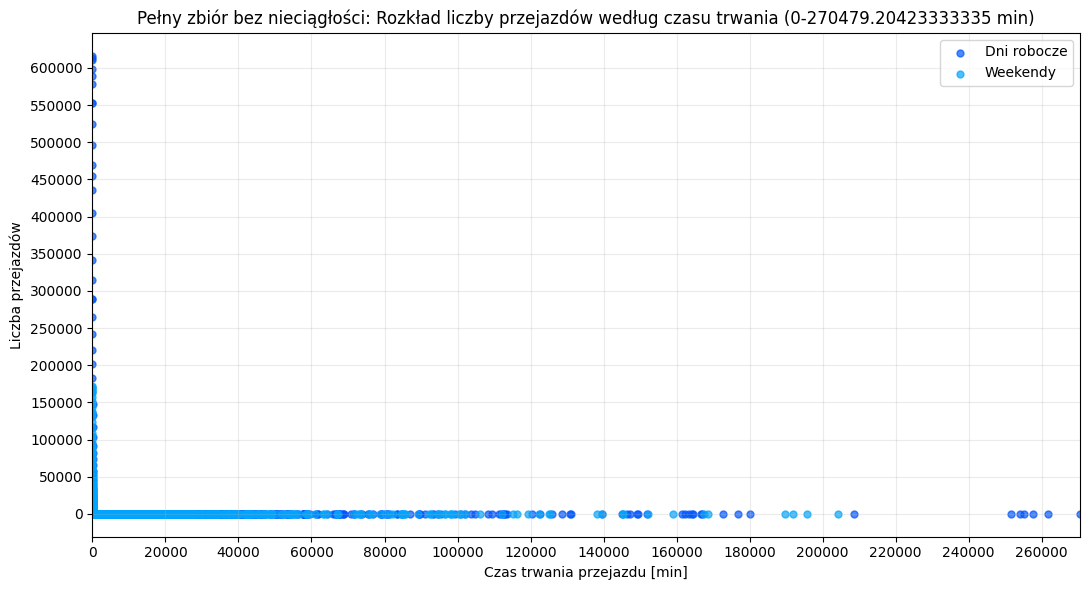

In [8]:
# ---------- Duration counts: weekdays vs weekends ----------

ax = dpu.plot_duration_counts(
    duration_counts_weekdays,
    duration_counts_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    title_prefix=DATASET_LABEL,
)
plt.tight_layout()
plt.show()

# 1.Histograms

In [9]:
# ---------- Preparing duration data ----------

duration_weekdays, duration_weekends = dpu.prepare_duration_data(
    dur_dist_data_weekdays,
    dur_dist_data_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

results = dpu.calculate_duration_log_binning_results(
    duration_weekdays,
    duration_weekends,
    lower_limit=duration_log_lower_limit,
    upper_limit=upper_limit,
    a_values=a_values,
)


a = 1.5
Number of bins: 45
First bin edges: [0.00326667 0.0049     0.00735    0.011025   0.0165375 ]
Last bin edges: [ 54180.92837261  81271.39255891 121907.08883836 182860.63325755
 270479.20423333]

a = 1.75
Number of bins: 33
First bin edges: [0.00326667 0.00571667 0.01000417 0.01750729 0.03063776]
Last bin edges: [ 36492.88788627  63862.55380098 111759.46915171 195579.0710155
 270479.20423333]

a = 2
Number of bins: 27
First bin edges: [0.00326667 0.00653333 0.01306667 0.02613333 0.05226667]
Last bin edges: [ 27402.78613333  54805.57226667 109611.14453333 219222.28906667
 270479.20423333]


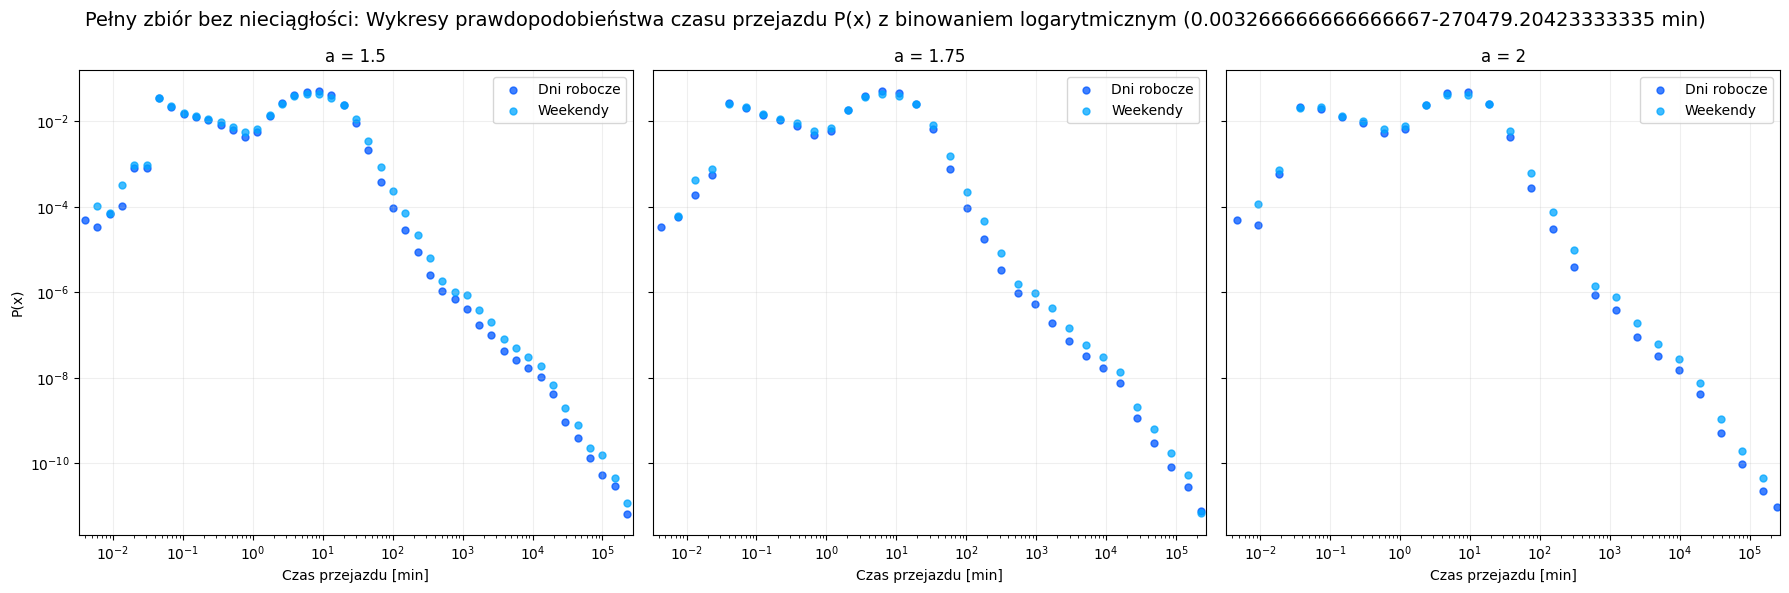

In [10]:
# ---------- Plotting logarithmic probability density ----------

fig, axes = dpu.plot_duration_log_probability(
    results,
    lower_limit=duration_log_lower_limit,
    upper_limit=upper_limit,
    a_values=a_values,
    title_prefix=DATASET_LABEL,
)
plt.show()

Zakres dopasowania:
x_min = 0.003266666666666667
x_max = 270479.20423333335

Dni robocze:
Nachylenie = -1.061
Wyraz wolny = -3.108

Weekendy:
Nachylenie = -1.095
Wyraz wolny = -2.788


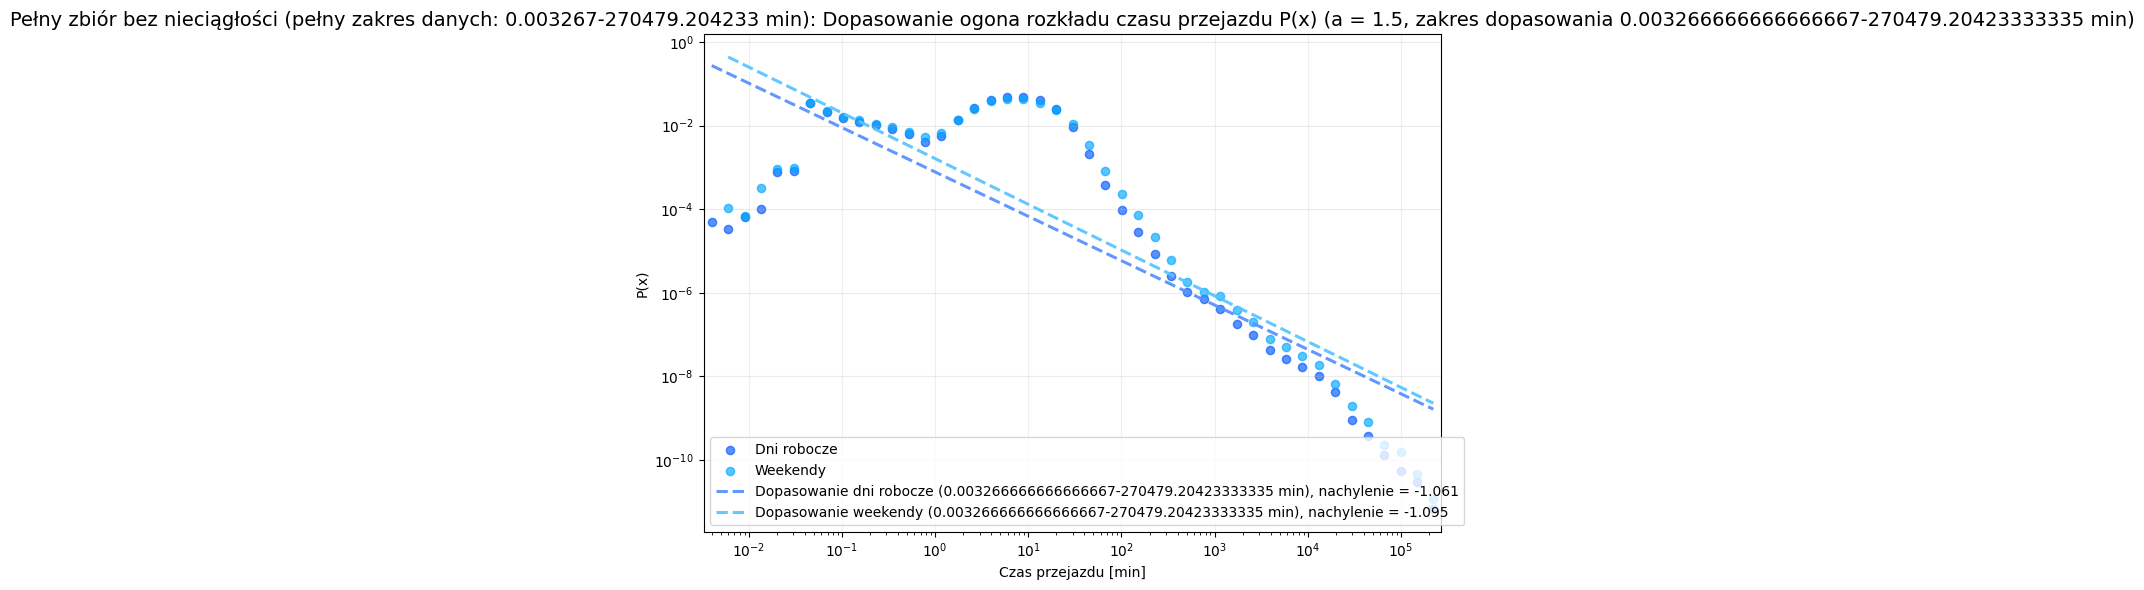

In [11]:
# ---------- Full-range log-log fit for weekdays and weekends ----------

full_range_fit = dpu.plot_duration_tail_fit(
    results,
    lower_limit=duration_log_lower_limit,
    upper_limit=upper_limit,
    a_value=1.5,
    x_min=duration_log_lower_limit,
    x_max=upper_limit,
    title_prefix=f"{DATASET_LABEL} ({duration_range_label})",
)
plt.tight_layout()
plt.show()

# Histogram prędkości

# Odległość przejazdów w linii prostej

In [12]:
# ---------- Straight-line distance between start and end stations ----------

ride_distance_data = dpu.prepared_ride_distance_data(dur_dist_data)

display(
    ride_distance_data["straight_line_distance_km"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99]
    )
)

display(
    ride_distance_data
    .sort_values("straight_line_distance_km", ascending=False)
    .head()
)

Liczba przejazdów: 16091818
Liczba przejazdów z brakującymi współrzędnymi: 0


count    1.609182e+07
mean     2.376724e+00
std      1.738575e+00
min      0.000000e+00
5%       3.420790e-01
50%      1.982218e+00
90%      4.703861e+00
95%      5.775892e+00
99%      8.088740e+00
max      1.696891e+01
Name: straight_line_distance_km, dtype: float64

,trip_id,start_date,end_date,total_duration_minutes,start_lat,start_lon,end_lat,end_lon,straight_line_distance_km
580061,137489640,2024-02-24 12:20:00,2024-02-24 14:06:00,105.405000,51.546326,-0.009935,51.463211,-0.215551,16.968915
12925974,137489653,2024-02-24 12:20:00,2024-02-24 14:06:00,105.153683,51.546326,-0.009935,51.463211,-0.215551,16.968915
14052822,140275736,2024-06-17 18:35:00,2024-06-17 19:40:00,65.797917,51.464786,-0.215619,51.541793,-0.004810,16.918216
13731906,140191949,2024-06-14 15:26:00,2024-06-14 16:26:00,60.530150,51.494224,-0.236770,51.541793,-0.004810,16.899189
14424928,140049573,2024-06-09 13:37:00,2024-06-09 14:44:00,67.649733,51.494224,-0.236770,51.541793,-0.004810,16.899189


In [13]:
dur_dist_data.head()

,bike_id,bike_model,end_date,end_lat,end_lon,end_station_id,end_station_name,speed_km_per_h,start_date,start_day_of_week,...,start_station_name,straight_line_distance_km,total_duration,total_duration_minutes,trip_id,previous_end_station_id,previous_end_date,previous_end_station_name,duration_min_bin,duration_counts
0,2.0,CLASSIC,2024-08-01 08:26:00,51.500744,-0.202759,1115.0,"Ilchester Place, Kensington",11.269322,2024-08-01 08:12:00,Thursday,...,"Finlay Street, Fulham",2.804527,14m 55s,14.931833,141622479,NaN,NaT,None,14.0,127329.0
1,2.0,CLASSIC,2024-08-01 13:43:00,51.494224,-0.236770,300037.0,"Ravenscourt Park Station, Hammersmith",8.507715,2024-08-01 13:26:00,Thursday,...,"Ilchester Place, Kensington",2.463470,17m 22s,17.373433,141631864,1115.0,2024-08-01 08:26:00,"Ilchester Place, Kensington",17.0,156737.0
2,2.0,CLASSIC,2024-08-03 12:37:00,51.494499,-0.228188,200166.0,"Southerton Road, Hammersmith",11.829568,2024-08-03 12:34:00,Saturday,...,"Ravenscourt Park Station, Hammersmith",0.594909,3m 1s,3.017400,141687538,300037.0,2024-08-01 13:43:00,"Ravenscourt Park Station, Hammersmith",3.0,379967.0
3,2.0,CLASSIC,2024-08-05 08:58:00,51.514767,-0.225787,200136.0,"BBC White City, White City",9.351433,2024-08-05 08:43:00,Monday,...,"Southerton Road, Hammersmith",2.259820,14m 29s,14.499300,141741326,200166.0,2024-08-03 12:37:00,"Southerton Road, Hammersmith",14.0,591814.0
4,2.0,CLASSIC,2024-09-05 13:15:00,51.514771,-0.122220,1007.0,"Drury Lane, Covent Garden",6.669502,2024-09-05 12:53:00,Thursday,...,"Bank of England Museum, Bank",2.396771,21m 33s,21.561767,142641262,1201.0,2024-09-05 12:00:00,"Bank of England Museum, Bank",21.0,715284.0


Liczba przejazdów w zakresie 0-270479.20423333335 min z policzoną prędkością: 15519413


count    1.551941e+07
mean     1.018795e+01
std      1.487166e+01
min      9.604555e-05
5%       3.454720e+00
50%      1.046150e+01
90%      1.433915e+01
95%      1.549358e+01
99%      1.770409e+01
99.5%    1.851606e+01
max      5.592687e+04
Name: speed_km_per_h, dtype: float64

/var/folders/8p/j63xl3c17439n25jbp9cyjg40000gn/T/ipykernel_17818/3040698239.py:23: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Users/artur/Studia/Rowerki/.venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


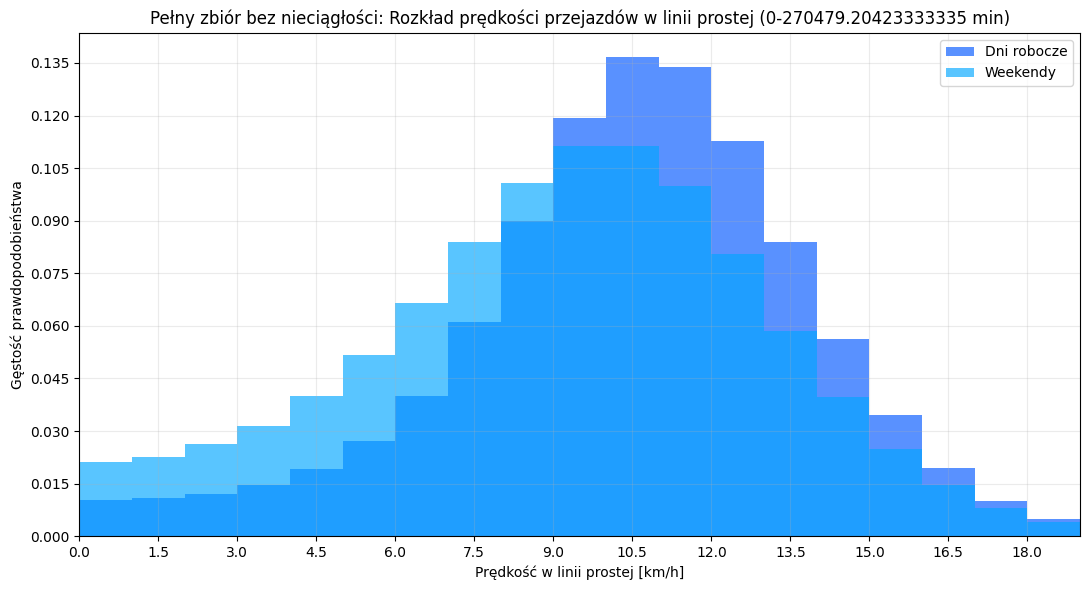

In [14]:
# ---------- Speed distribution for rides across the full duration range ----------

speed_distribution_data, speed_weekdays, speed_weekends = dpu.prepare_speed_distribution_data(
    dur_dist_data,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
)

display(
    speed_distribution_data["speed_km_per_h"].describe(
        percentiles=[0.05, 0.5, 0.9, 0.95, 0.99, 0.995]
    )
)

ax = dpu.plot_speed_histogram(
    speed_distribution_data,
    speed_weekdays,
    speed_weekends,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    title_prefix=DATASET_LABEL,
)
plt.tight_layout()
plt.show()


a = 1.5
Number of bins: 50
First bin edges: [9.60455501e-05 1.44068325e-04 2.16102488e-04 3.24153732e-04
 4.86230597e-04]
Last bin edges: [12096.92992473 18145.3948871  27218.09233065 40827.13849598
 55926.86651732]

a = 1.75
Number of bins: 37
First bin edges: [9.60455501e-05 1.68079713e-04 2.94139497e-04 5.14744120e-04
 9.00802210e-04]
Last bin edges: [10063.12471276 17610.46824734 30818.31943284 53932.05900747
 55926.86651732]

a = 2
Number of bins: 30
First bin edges: [9.60455501e-05 1.92091100e-04 3.84182200e-04 7.68364401e-04
 1.53672880e-03]
Last bin edges: [ 6445.5077595  12891.015519   25782.031038   51564.062076
 55926.86651732]


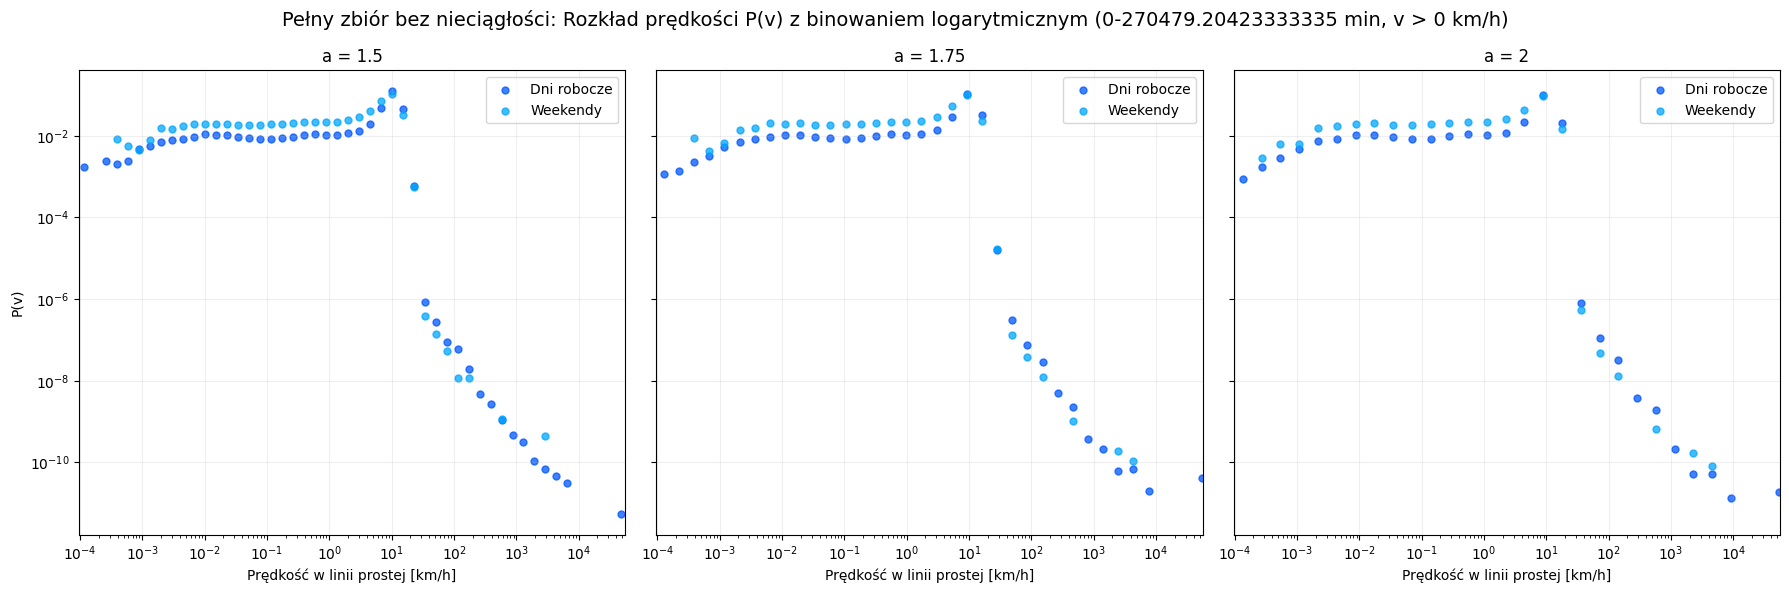

In [15]:
# ---------- Logarithmic speed distribution ----------

speed_results, min_speed, max_speed = dpu.calculate_speed_log_binning_results(
    speed_distribution_data,
    speed_weekdays,
    speed_weekends,
    speed_a_values=speed_a_values,
)

fig, axes = dpu.plot_speed_log_probability(
    speed_results,
    min_speed,
    max_speed,
    lower_limit=lower_limit,
    upper_limit=upper_limit,
    speed_a_values=speed_a_values,
    title_prefix=DATASET_LABEL,
)
plt.show()

In [16]:
# ---------- Rides with speed close to 40 km/h ----------

rides_speed_39_40 = dpu.rides_with_speed_between(
    speed_distribution_data,
    39,
    40,
)

display(rides_speed_39_40)

,trip_id,start_date,end_date,start_station_name,end_station_name,total_duration_minutes,straight_line_distance_km,speed_km_per_h
2125250,138593898,2024-04-15 15:43:00,2024-04-15 15:46:00,"Michael Road, Walham Green","Flood Street, Chelsea",3.004850,1.954359,39.024093
43380,142074065,2024-08-15 22:09:00,2024-08-15 22:10:00,"Hollybush Gardens, Bethnal Green","Pritchard's Road, Bethnal Green",0.889400,0.580125,39.135938
4328993,153941110,2025-11-20 05:49:00,2025-11-20 05:51:00,"Farringdon Lane, Clerkenwell","Wood Street, Guildhall",1.887750,1.234736,39.244700
13726741,145308290,2024-12-20 06:00:00,2024-12-20 06:03:00,"Crimscott Street, Bermondsey","Crosswall, Tower",2.700367,1.782988,39.616586
14129371,145133979,2024-12-11 15:45:00,2024-12-11 15:46:00,"Cheapside, Bank","St. Mary Axe, Aldgate",1.285650,0.850252,39.680405
4082956,153826780,2025-11-15 10:20:00,2025-11-15 10:25:00,"Ilchester Gardens, Bayswater","Colet Gardens, Hammersmith",4.467733,2.959367,39.743203
13781561,138593057,2024-04-15 14:45:00,2024-04-15 14:47:00,"Gower Place , Euston","The Tennis Courts, The Regent's Park",1.903950,1.264402,39.845656
15350079,150255636,2025-07-10 19:33:00,2025-07-10 19:36:00,"Clifford Street, Mayfair","Warwick Row, Westminster",2.118500,1.408820,39.900490


In [17]:
# ---------- Rides with speed close to 10^-2 km/h ----------

rides_speed_around_001 = dpu.rides_with_speed_between(
    speed_distribution_data,
    0.0095,
    0.0105,
)

display(rides_speed_around_001)

,trip_id,start_date,end_date,start_station_name,end_station_name,total_duration_minutes,straight_line_distance_km,speed_km_per_h
11096682,141868476,2024-08-09 13:26:00,2024-08-23 02:56:00,"Storey's Gate, Westminster","Courland Grove, Wandsworth Road",19530.509583,3.093996,0.009505
8693509,141026809,2024-07-13 03:19:00,2024-07-20 08:01:00,"Bonny Street, Camden Town","Killick Street, King's Cross",10362.755083,1.643190,0.009514
12444492,139062024,2024-05-05 07:30:00,2024-05-05 13:11:00,"Queensway, Kensington Gardens","Black Lion Gate, Kensington Gardens",340.939733,0.054067,0.009515
6709647,150849513,2025-07-31 11:27:00,2025-08-10 22:52:00,"Kingsway Southbound, Strand","Windsor Terrace, Hoxton",15085.009067,2.392791,0.009517
3437783,149528334,2025-06-17 18:04:00,2025-07-03 17:26:00,"Tower Gardens , Tower","Risinghill Street, Angel",23002.003683,3.650592,0.009522
...,...,...,...,...,...,...,...,...
4142881,143971301,2024-10-24 16:21:00,2024-11-25 11:43:00,"Queen Mary's, Mile End","St John's Crescent, Brixton",45861.761383,7.991561,0.010455
5128857,144194198,2024-11-01 12:59:00,2024-11-15 18:11:00,"Ada Street, Hackney Central","Risinghill Street, Angel",20472.904267,3.571386,0.010467
7997612,144194194,2024-11-01 12:58:00,2024-11-15 18:11:00,"Ada Street, Hackney Central","Risinghill Street, Angel",20472.717800,3.571386,0.010467
957749,149583739,2025-06-19 09:41:00,2025-06-19 15:30:00,"Shadwell Station, Shadwell","Watney Street, Shadwell",348.568533,0.060891,0.010481
